In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


movies = pd.read_csv("movies_updated.csv")
print(movies.head())




                                             name rating      genre  year  \
0                                     The Shining      R      Drama  1980   
1                                 The Blue Lagoon      R  Adventure  1980   
2  Star Wars: Episode V - The Empire Strikes Back     PG     Action  1980   
3                                       Airplane!     PG     Comedy  1980   
4                                      Caddyshack      R     Comedy  1980   

                        released  score    votes         director  \
0  June 13, 1980 (United States)    8.4   927000  Stanley Kubrick   
1   July 2, 1980 (United States)    5.8    65000   Randal Kleiser   
2  June 20, 1980 (United States)    8.7  1200000   Irvin Kershner   
3   July 2, 1980 (United States)    7.7   221000     Jim Abrahams   
4  July 25, 1980 (United States)    7.3   108000     Harold Ramis   

                    writer            star         country    budget  \
0             Stephen King  Jack Nicholson  United

In [ ]:
"""Task 1: Explore the Dataset"""
print(movies.info())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   name       4000 non-null   str    
 1   rating     3960 non-null   str    
 2   genre      4000 non-null   str    
 3   year       4000 non-null   int64  
 4   released   4000 non-null   str    
 5   score      4000 non-null   float64
 6   votes      4000 non-null   int64  
 7   director   4000 non-null   str    
 8   writer     3999 non-null   str    
 9   star       3999 non-null   str    
 10  country    4000 non-null   str    
 11  budget     4000 non-null   int64  
 12  gross      3831 non-null   float64
 13  company    3990 non-null   str    
 14  runtime,,  4000 non-null   str    
dtypes: float64(2), int64(3), str(10)
memory usage: 468.9 KB
None


In [9]:
print(movies.describe())

              year        score         votes        budget         gross
count  4000.000000  4000.000000  4.000000e+03  4.000000e+03  3.831000e+03
mean   1991.191500     6.321950  5.449450e+04  1.542740e+07  4.172202e+07
std       5.934529     0.977101  1.427738e+05  2.248639e+07  9.259504e+07
min    1980.000000     2.200000  5.100000e+01  0.000000e+00  3.090000e+02
25%    1986.000000     5.700000  4.300000e+03  0.000000e+00  2.835743e+06
50%    1991.000000     6.400000  1.300000e+04  7.000000e+06  1.183822e+07
75%    1996.000000     7.000000  4.500000e+04  2.100000e+07  3.560495e+07
max    2001.000000     9.300000  2.400000e+06  2.000000e+08  2.201647e+09


In [19]:
# Questions
# 1. How many movies are in the dataset?
print("Total number of movies:", len(movies))
# 2. Which columns are numerical?
num_col = movies.select_dtypes(include=['int64',"float64"]).columns
print("Numerical columns",num_col.to_list())
# 3. Which columns are categorical?
cat_col = movies.select_dtypes("str").columns
print("Categorical columns: ",cat_col.to_list())

Total number of movies: 4000
Numerical columns ['year', 'score', 'votes', 'budget', 'gross']
Categorical columns:  ['name', 'rating', 'genre', 'released', 'director', 'writer', 'star', 'country', 'company', 'runtime,,']


Number of movies released each year.
year
1980     92
1981    113
1982    126
1983    144
1984    168
1985    200
1986    200
1987    200
1988    200
1989    200
1990    200
1991    200
1992    200
1993    200
1994    200
1995    200
1996    200
1997    200
1998    200
1999    200
2000    200
2001    157
Name: count, dtype: int64
Year with most movies: 1985 (200 movies)


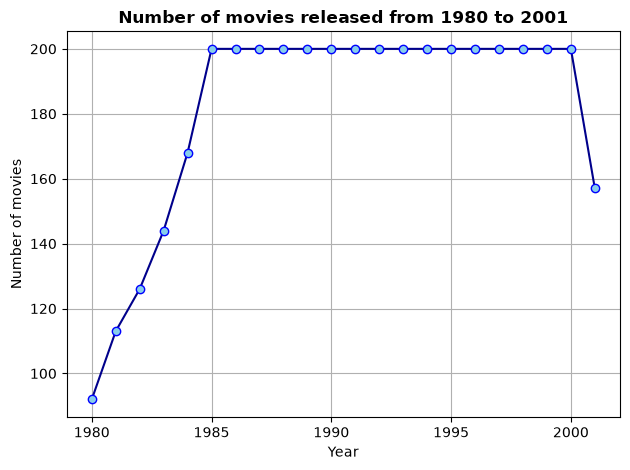

In [ ]:
"""Task 2: Number of Movies Released Each
Year
Use Pandas to determine the number of movies released each year.
Create a line plot to visualize the trend.
Questions

# 1. Which year has the most movies?
# from 1985 to 2000 with 200 movies per year
# 2. Does the number of movies increase over time?
# it initially shows growth 1980 - 1985 but become flat from year 1985 to 2000 and drops in 2001.
# 3. What trend do you observe?

growth trend: 1980 - 1985
platue or flat: 1985 - 2000
drop: 2001"""

movies_per_year = movies["year"].value_counts().sort_index()
print("Number of movies released each year.")
print(movies_per_year)

max_year = movies_per_year.idxmax()
max_count = movies_per_year.max()

print(f"Year with most movies: {max_year} ({max_count} movies)")

plt.plot(movies_per_year.index,movies_per_year.values,marker="o",mfc="skyblue",mec="blue",color="darkblue")
plt.title("Number of movies released from 1980 to 2001",fontweight="bold")
plt.ylabel("Number of movies")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()


genre
Comedy       1355
Drama         807
Action        775
Crime         302
Adventure     231
Biography     175
Horror        158
Animation     113
Fantasy        33
Mystery        13
Name: count, dtype: int64
Top 10 genres with the most movies: ['Comedy', 'Drama', 'Action', 'Crime', 'Adventure', 'Biography', 'Horror', 'Animation', 'Fantasy', 'Mystery']


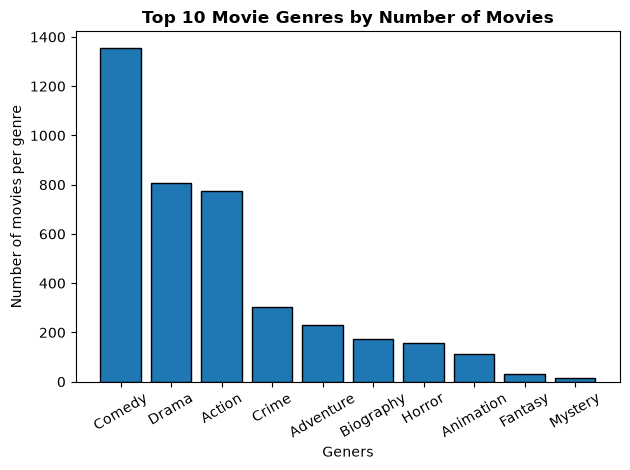

In [ ]:
"""Task 3: Top 10 Movie Genres
Find the top 10 genres with the largest number of movies.
Create a vertical bar chart.
Questions
1. Which genre contains the most movies?
    * Comedy
2. Which genre contains the fewest movies among the top 10?
    * Mystery
3. Why is a bar chart suitable for this task?
    * It represents catagorical variables with descrete numerical value and 
    and make it easy to observe based on relative magnitudes or height.
    """



top_genres = movies["genre"].value_counts().head(10)
print(top_genres)
print(f"Top 10 genres with the most movies: {top_genres.index.to_list()}")

plt.bar(top_genres.index,top_genres.values,edgecolor='black')
plt.xticks(rotation=30)
plt.title('Top 10 Movie Genres by Number of Movies',fontweight="bold" ,fontsize=12)
plt.ylabel("Number of movies per genre")
plt.xlabel("Geners")
plt.tight_layout()
plt.show()

Top 10 directors with the largest number of movies.
director
Woody Allen         22
Clint Eastwood      16
Directors           16
Barry Levinson      16
Walter Hill         15
Sidney Lumet        15
Joel Schumacher     15
John Carpenter      14
Steven Spielberg    14
Ron Howard          14
Name: count, dtype: int64


Text(0.5, 0, 'Number of movies per Director')

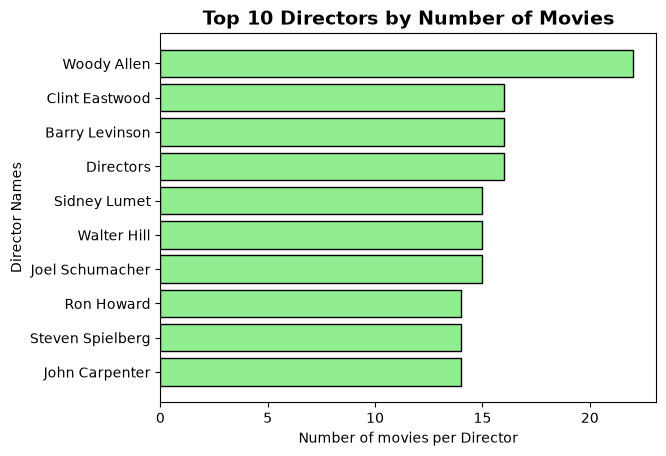

In [ ]:
"""Task 4: Top 10 Directors
Find the top 10 directors with the largest number of movies.
Create a horizontal bar chart.
Questions
1. Which director produced the most movies?
    * Woody Allen: 22 movies
2. Why is a horizontal bar chart more suitable than a vertical bar chart for this visualization?
    * A horizontal bar chart is much better here because the categorical labels
        in our case director names might be long so it is better than the vertical in here.
"""
top_directors = movies["director"].value_counts().head(10)
print("Top 10 directors with the largest number of movies.")
print(top_directors)


plt.barh(top_directors.sort_values(ascending=True).index,top_directors.sort_values(ascending=True).values,edgecolor="black",color="lightgreen")
plt.title('Top 10 Directors by Number of Movies',fontweight="bold" ,fontsize=14)
plt.ylabel("Director Names")
plt.xlabel("Number of movies per Director")

In [ ]:
"""Task 5: Distribution of Movie Ratings

Using the score column, create a histogram.


Questions

1. Which score range contains the largest number of movies?

2. Are most movies highly rated?

3. Are low-rated movies common?

4. What does the histogram tell you about movie ratings?"""



movie_score = pd.cut(movies["score"],bins=[0,3,4,5,6,7,8,9,10])
print(movie_score)





NameError: name 'movies' is not defined

genre
History      8.300000
Music        7.200000
Biography    7.052000
Animation    6.883186
Drama        6.673606
Crime        6.645033
Family       6.550000
Mystery      6.500000
Romance      6.400000
Comedy       6.179410
Adventure    6.151948
Fantasy      6.024242
Action       6.014968
Sci-Fi       5.983333
Thriller     5.890909
Horror       5.744304
Western      5.666667
Name: score, dtype: float64


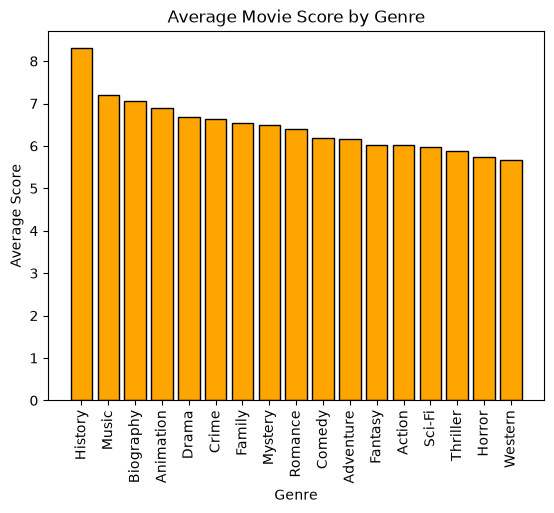

In [116]:
"""Task 6: Average Movie Score by Genre



Calculate the average score for each genre.

Sort the results from highest to lowest.

Create a bar chart.

Questions

1. Which genre has the highest average score?

    * history

2. Which genre has the lowest average score?

    * Western

3. Are the most popular genres also the highest rated?

    *Somehow"""

genre_avg_score = movies.groupby('genre')['score'].mean().sort_values(ascending=False)
print(genre_avg_score)
plt.bar(genre_avg_score.index,genre_avg_score.values,edgecolor="black", color="orange")
plt.xticks(rotation=90)
plt.title('Average Movie Score by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Score')
plt.show()


                                                   name         gross
3045                                            Titanic  2.201647e+09
2448                                      The Lion King  1.083721e+09
2245                                      Jurassic Park  1.033928e+09
3451          Star Wars: Episode I - The Phantom Menace  1.027083e+09
3843              Harry Potter and the Sorcerer's Stone  1.006968e+09
3845  The Lord of the Rings: The Fellowship of the Ring  8.976901e+08
2844                                   Independence Day  8.174009e+08
209                          E.T. the Extra-Terrestrial  7.929106e+08
2445                                       Forrest Gump  6.782261e+08
3453                                    The Sixth Sense  6.728063e+08


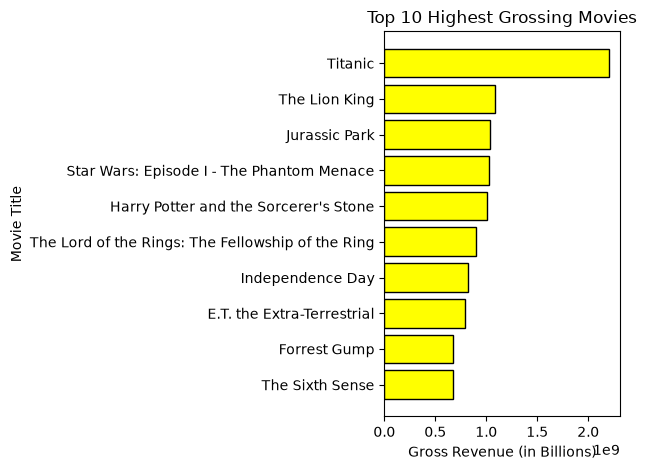

In [120]:
"""Task 7: Top 10 Highest Grossing Movies

Find the top 10 movies with the highest gross revenue.

Create a horizontal bar chart.

Questions


1. Which movie earned the highest revenue?

2. Is there a large difference between the highest-grossing movie and the others?

3. What observations can you make from the graph?"""

top_grossing = movies.nlargest(10,'gross')
print(top_grossing[['name',"gross"]])
top_grossing_sorted = top_grossing.sort_values('gross', ascending=True)
plt.barh(top_grossing_sorted['name'], top_grossing_sorted['gross'], color='yellow', edgecolor='black')
plt.title('Top 10 Highest Grossing Movies')
plt.xlabel('Gross Revenue (in Billions)')
plt.ylabel('Movie Title')
plt.tight_layout()

In [ ]:
# Final Storytelling Question
# Imagine you are a data analyst working for a movie production company.
# Write a short report (5–8 sentences) describing your findings.
# Your report should answer the following questions:
# 1. Which genre is the most common?
# 2. Which genre has the highest average rating?
# 3. Are most movies highly rated?
# 4. Has movie production increased over time?
# 5. Which movie earned the highest revenue?
# 6. What recommendations would you give to a movie studio based on

"""Based on the analysis of the movie dataset, Comedy is the 
most common genre with 1,355 movies, much higher than any other
genre. However, Comedy movies have an average rating of only 6.18,
while History movies have the highest average rating of 8.3. Most
movies receive ratings around 6.3, showing that highly rated movies 
are less common.

The number of movies produced increased steadily until the early 
1980s and then stayed at about 200 movies per year. This suggests
 a stable and competitive movie market. In terms of revenue, 
 Titanic was the highest-grossing movie, earning about $2.2 billion 
 and showing the strong earning potential of large-scale romantic dramas.

Based on these findings, the studio should invest more in high-quality
genres such as Biography, Drama, and History to improve its reputation
and ratings. It should also consider producing a large-scale historical
romance or epic drama, similar to Titanic, while focusing on strong writing 
and directing to create movies that stand out from the average."""